# Per-game climatology & threshold bands — men's and women's World Cups
Two composition views by tournament (stacked bars, **left**) plus the absolute in-play peak WBGT by year (**right**; a trend is fitted for men only). **Climatology bands** split each game by where its game-window MEAN WBGT falls in the stadium × day-of-year (±7 d) **1960–1990** climatology (<75th / 75–90th / 90–95th / >95th percentile / record above the historical max). **Threshold bands** split each game by its PEAK in-play WBGT against the FIFPRO/FIFA thresholds (<26 / 26–28 / 28–32 / ≥32 °C). Four figures: 2 views × men/women.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# set ROOT to the bundle path if you move this notebook
ROOT = "/glade/derecho/scratch/gavinmad/shared/Heathack"
PROC = os.path.join(ROOT, "data", "processed")
plt.rcParams.update({"font.size": 13, "figure.dpi": 120})
from scipy import stats
DF = {g: pd.read_csv(os.path.join(PROC, f"pergame_anomaly_summary_{g}.csv")) for g in ["men", "women"]}
{g: len(v) for g, v in DF.items()}

{'men': 911, 'women': 348}

/glade/derecho/scratch/gavinmad/tmp/ipykernel_94974/360465436.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_anomaly_bands_men.png


/glade/derecho/scratch/gavinmad/tmp/ipykernel_94974/360465436.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_absolute_bands_men.png


/glade/derecho/scratch/gavinmad/tmp/ipykernel_94974/360465436.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_anomaly_bands_women.png


/glade/derecho/scratch/gavinmad/tmp/ipykernel_94974/360465436.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_absolute_bands_women.png


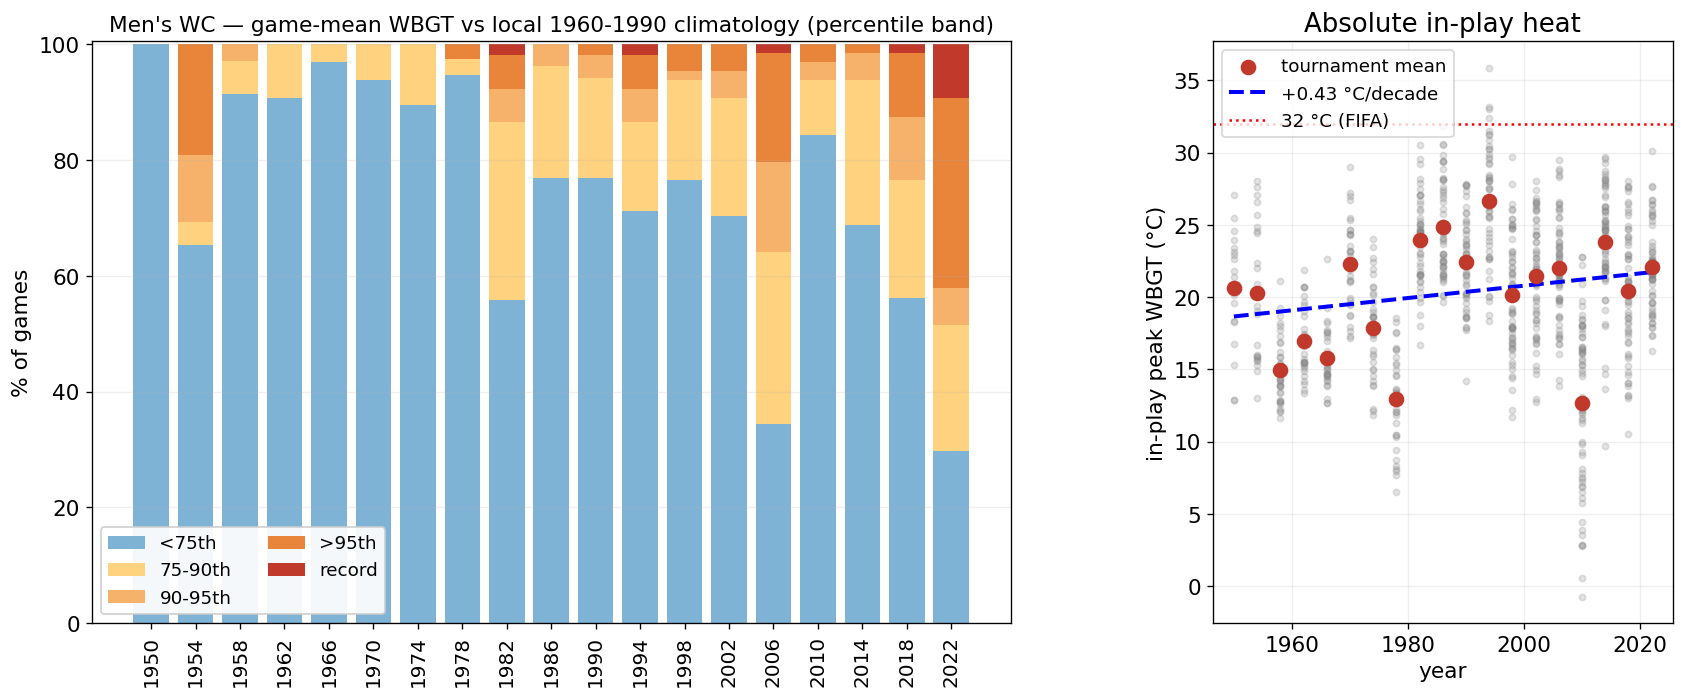

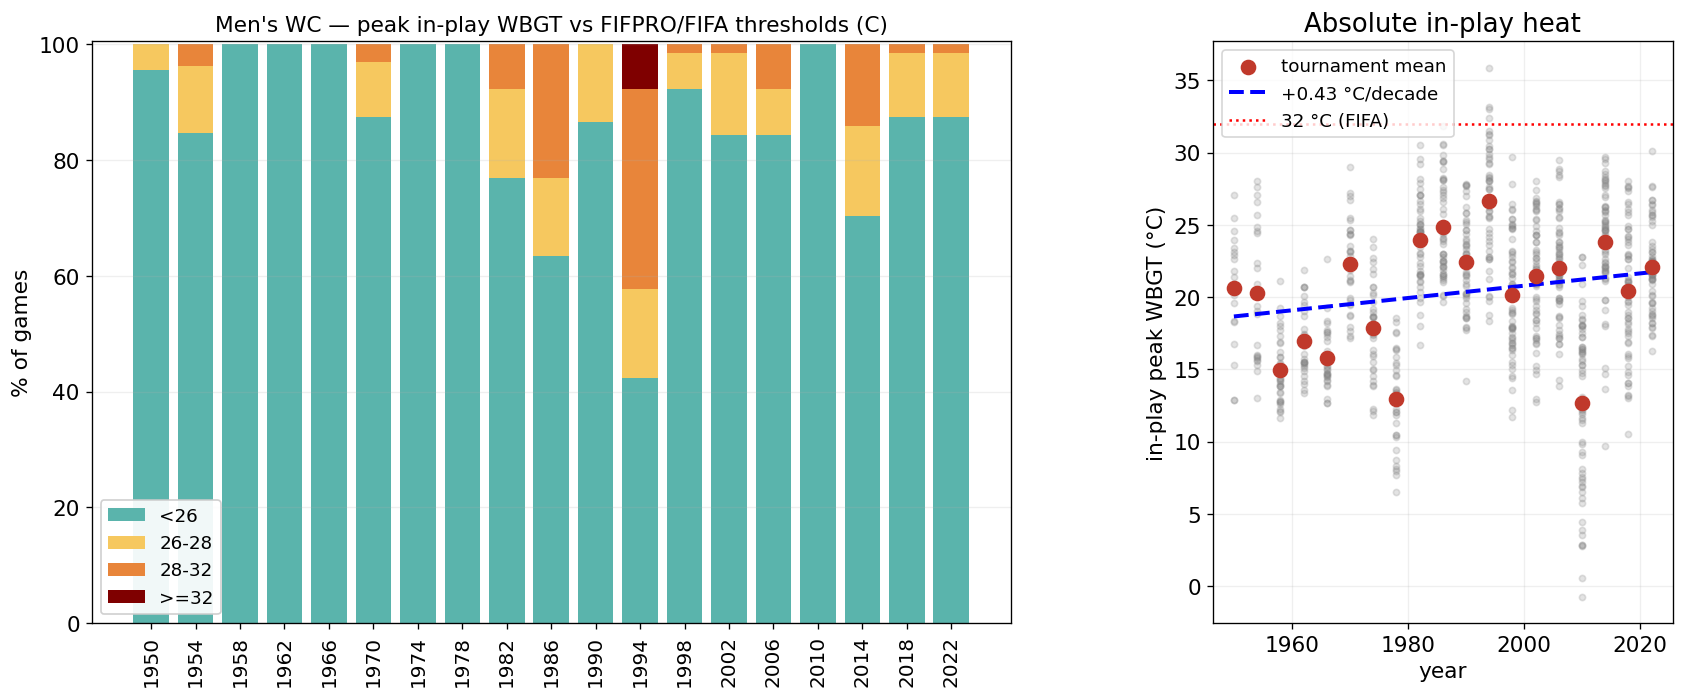

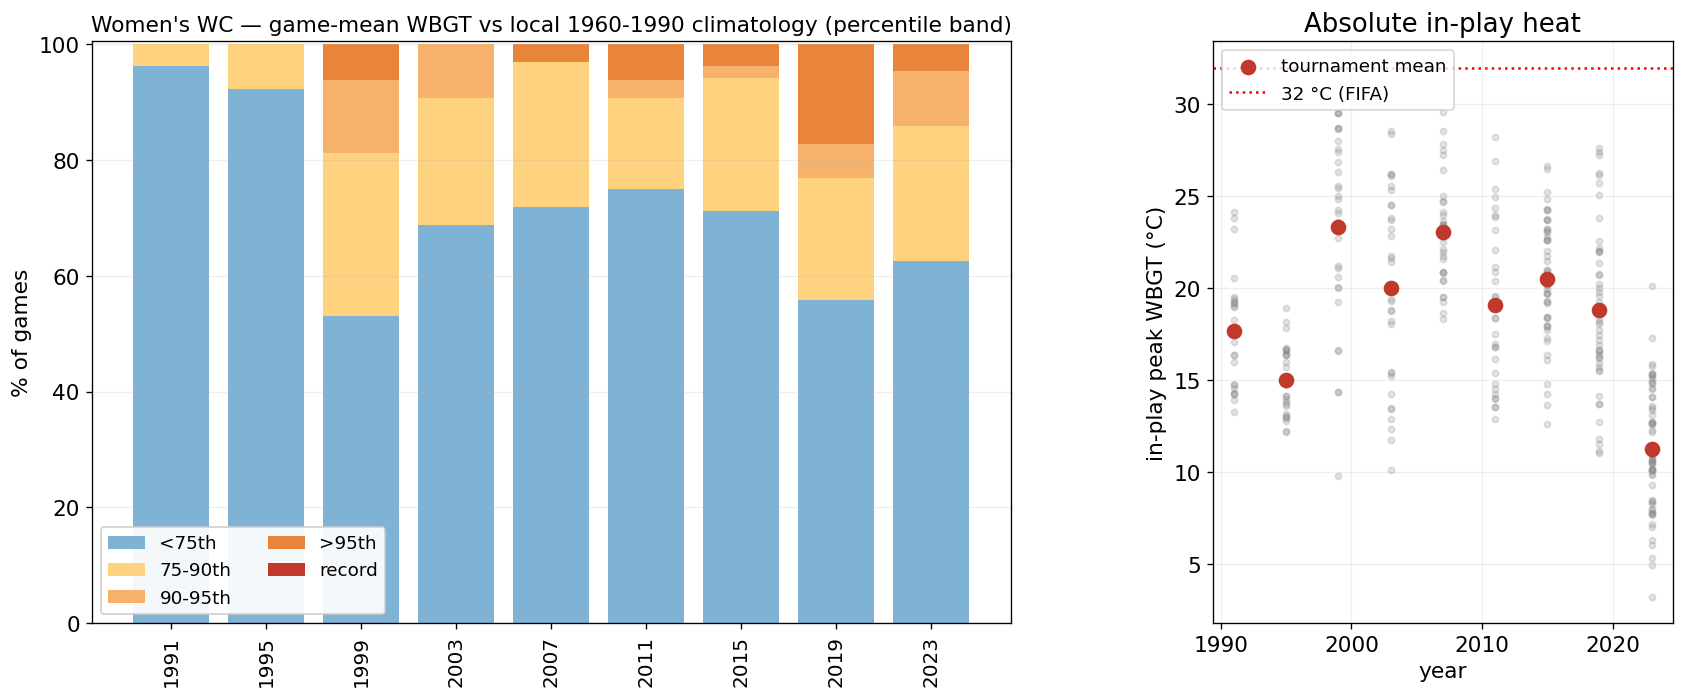

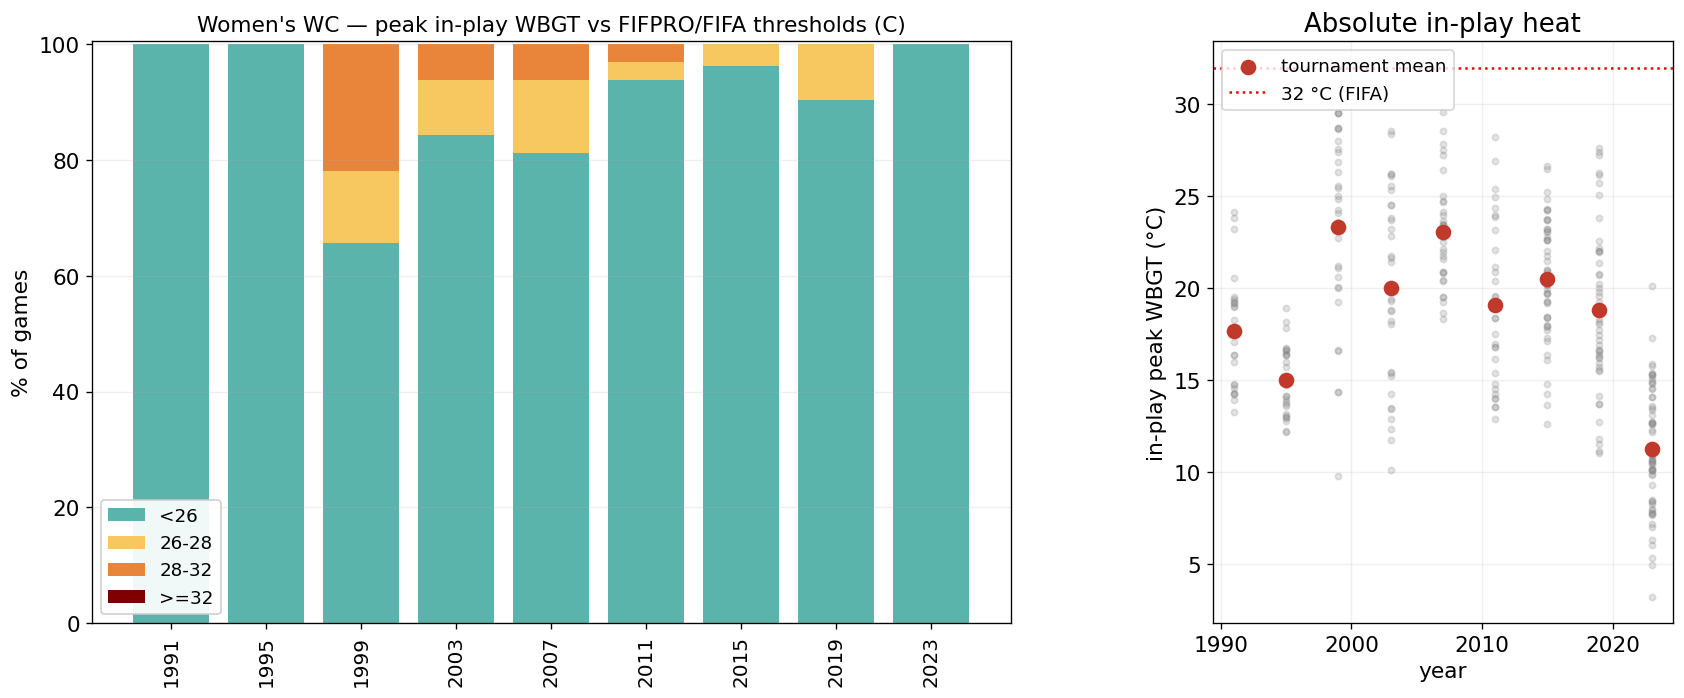

In [2]:
def right_panel(ax, d, trend):
    ax.scatter(d.year, d.gw_wbgt_max, s=14, alpha=0.22, color="grey")
    tm = d.groupby("year").gw_wbgt_max.mean()
    ax.scatter(tm.index, tm.values, s=70, color="#c0392b", zorder=6, label="tournament mean")
    if trend:
        sl, ic, r, p, _ = stats.linregress(d.year, d.gw_wbgt_max)
        xs = np.array([d.year.min(), d.year.max()])
        ax.plot(xs, ic + sl * xs, "b--", lw=2.4, label=f"{sl*10:+.2f} °C/decade")
    ax.axhline(32, color="red", ls=":", lw=1.5, label="32 °C (FIFA)")
    ax.set_ylabel("in-play peak WBGT (°C)"); ax.set_xlabel("year"); ax.set_title("Absolute in-play heat")
    ax.legend(fontsize=11, loc="upper left"); ax.grid(alpha=0.2)

def clim_band(r):                                    # game-mean WBGT position in the 1960-1990 climatology
    if r.above_record: return "record"
    if r.above_p95:    return ">95th"
    if r.above_p90:    return "90-95th"
    if r.above_p75:    return "75-90th"
    return "<75th"

def stacked(gender, kind):
    d = DF[gender].copy(); yrs = sorted(d.year.unique())
    if kind == "clim":
        d["b"] = [clim_band(r) for r in d.itertuples()]
        ORDER = ["<75th", "75-90th", "90-95th", ">95th", "record"]
        COL = ["#7fb3d5", "#ffd27f", "#f6b26b", "#e8853a", "#c0392b"]
        title = f"{gender.title()}'s WC — game-mean WBGT vs local 1960-1990 climatology (percentile band)"
        tag, ncol = "anomaly", 2
    else:
        d["b"] = pd.cut(d.gw_wbgt_max, [-100, 26, 28, 32, 100], right=False,
                        labels=["<26", "26-28", "28-32", ">=32"]).astype(str)
        ORDER = ["<26", "26-28", "28-32", ">=32"]
        COL = ["#5ab4ac", "#f6c85f", "#e8853a", "#7f0000"]
        title = f"{gender.title()}'s WC — peak in-play WBGT vs FIFPRO/FIFA thresholds (C)"
        tag, ncol = "absolute", 1
    pct = (d.groupby(["year", "b"]).size().unstack(fill_value=0)
           .reindex(index=yrs).reindex(columns=ORDER, fill_value=0))
    pct = pct.div(pct.sum(1), axis=0) * 100
    fig = plt.figure(figsize=(17, 6.3)); gs = fig.add_gridspec(1, 3, width_ratios=[2, 0, 1], wspace=0.22)
    axA = fig.add_subplot(gs[0, 0]); axB = fig.add_subplot(gs[0, 2])
    x = np.arange(len(yrs)); bottom = np.zeros(len(yrs))
    for lab, c in zip(ORDER, COL):
        v = pct[lab].values; axA.bar(x, v, bottom=bottom, color=c, label=lab); bottom += v
    axA.set_xticks(x); axA.set_xticklabels(yrs, rotation=90, fontsize=12)
    axA.set_ylim(0, 100.5); axA.set_ylabel("% of games"); axA.set_title(title, fontsize=13)
    axA.legend(loc="lower left", fontsize=11, framealpha=0.92, ncol=ncol); axA.grid(alpha=0.2, axis="y")
    right_panel(axB, d, trend=(gender == "men"))
    fig.tight_layout()
    out = os.path.join(ROOT, f"figures/03_climatology/pergame_{tag}_bands_{gender}.png")
    fig.savefig(out, dpi=200, bbox_inches="tight"); print("wrote", out)

for g in ["men", "women"]:
    stacked(g, "clim")      # 5 climatology-percentile bands
    stacked(g, "abs")       # absolute FIFPRO/FIFA threshold bands

/glade/derecho/scratch/gavinmad/tmp/ipykernel_94974/3178643477.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_anomaly_bands_combined.png


/glade/derecho/scratch/gavinmad/tmp/ipykernel_94974/3178643477.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/03_climatology/pergame_absolute_bands_combined.png


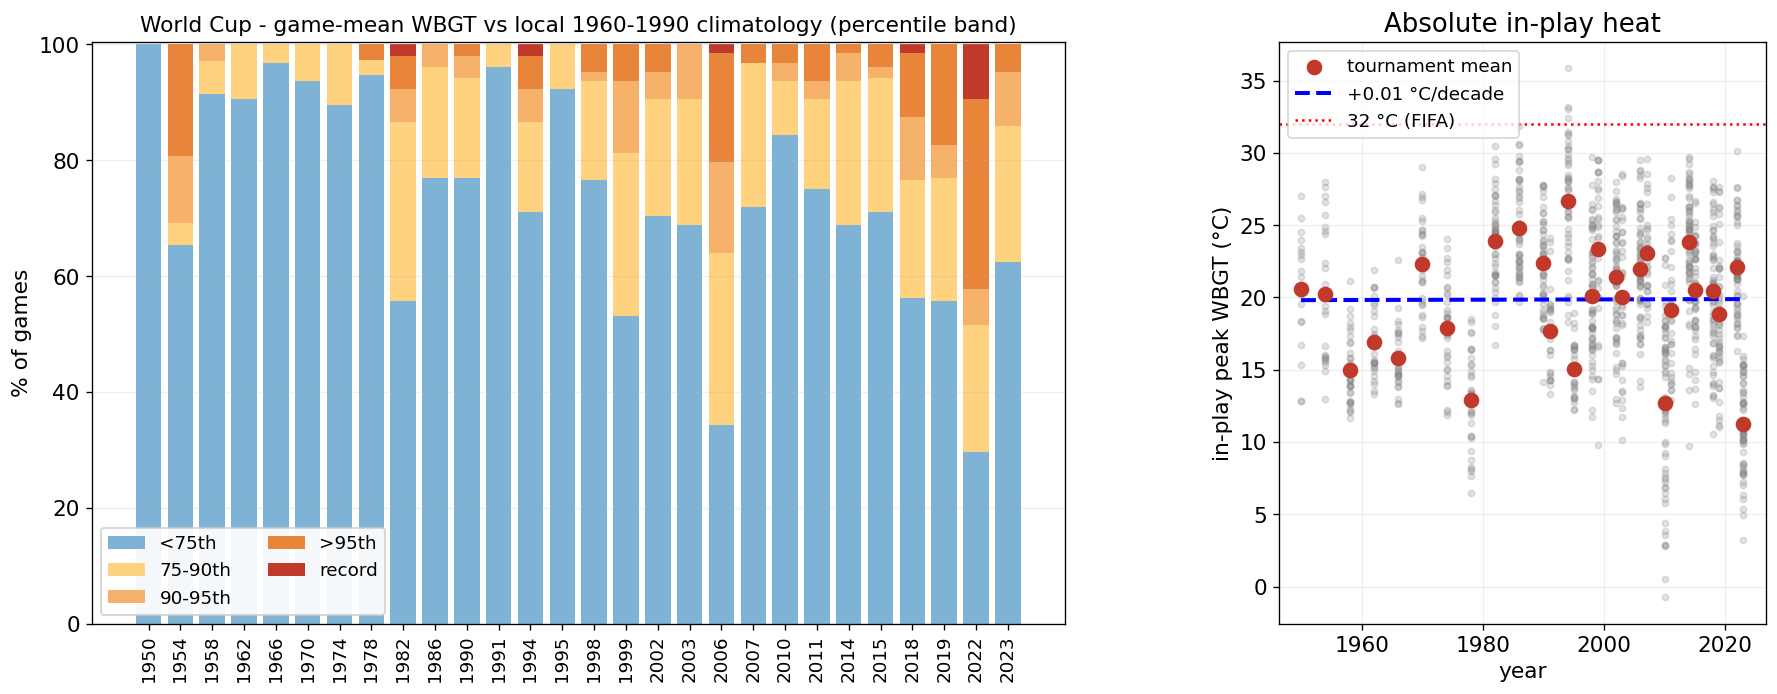

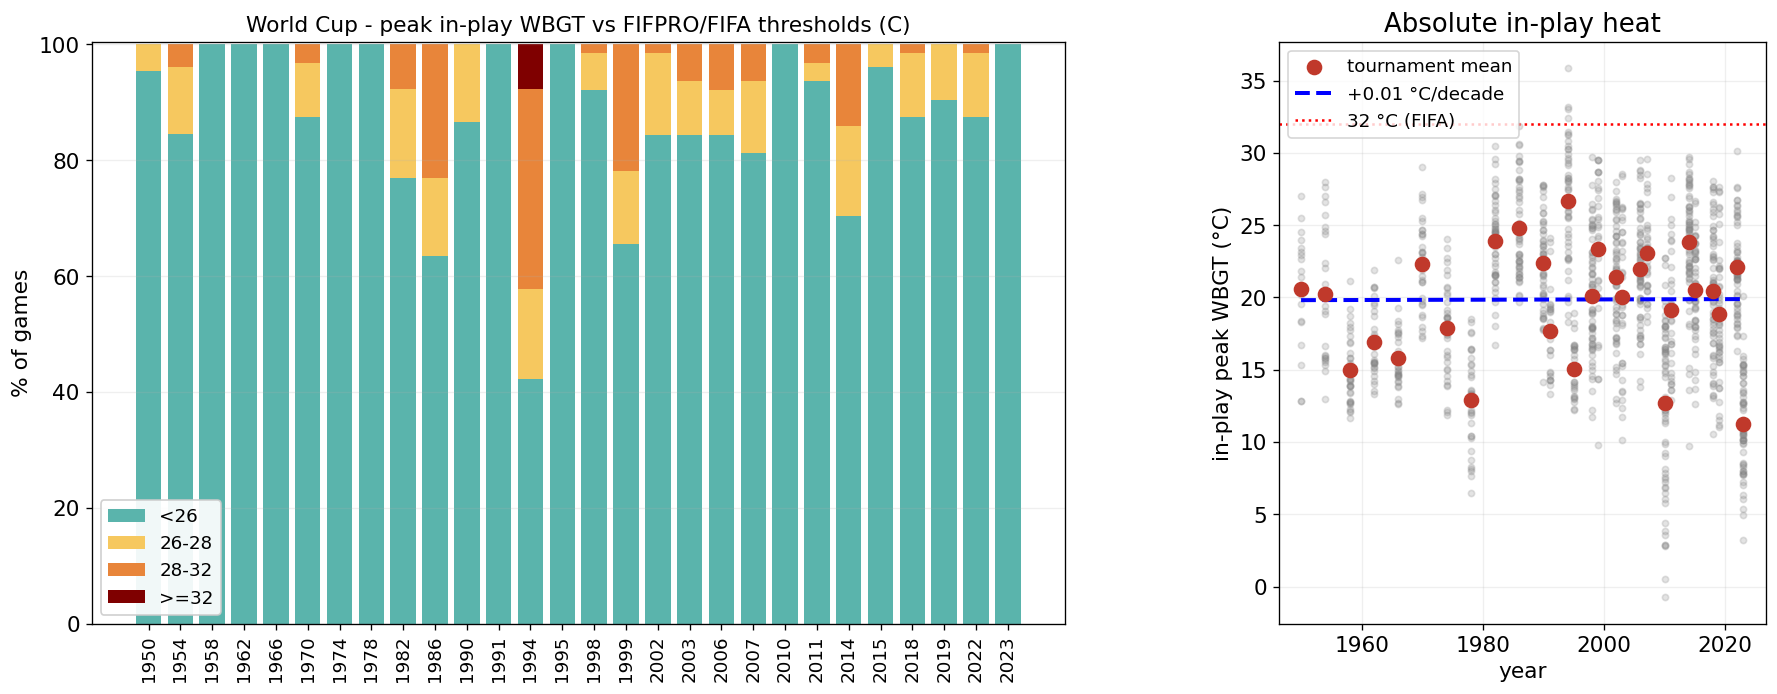

In [3]:
COMB = pd.concat([DF["men"], DF["women"]], ignore_index=True)

def stacked_combined(kind):
    d = COMB.copy(); yrs = sorted(d.year.unique())
    if kind == "clim":
        d["b"] = [clim_band(r) for r in d.itertuples()]
        ORDER = ["<75th", "75-90th", "90-95th", ">95th", "record"]
        COL = ["#7fb3d5", "#ffd27f", "#f6b26b", "#e8853a", "#c0392b"]
        title = "World Cup - game-mean WBGT vs local 1960-1990 climatology (percentile band)"
        tag, ncol = "anomaly", 2
    else:
        d["b"] = pd.cut(d.gw_wbgt_max, [-100, 26, 28, 32, 100], right=False,
                        labels=["<26", "26-28", "28-32", ">=32"]).astype(str)
        ORDER = ["<26", "26-28", "28-32", ">=32"]
        COL = ["#5ab4ac", "#f6c85f", "#e8853a", "#7f0000"]
        title = "World Cup - peak in-play WBGT vs FIFPRO/FIFA thresholds (C)"
        tag, ncol = "absolute", 1
    pct = (d.groupby(["year", "b"]).size().unstack(fill_value=0)
           .reindex(index=yrs).reindex(columns=ORDER, fill_value=0))
    pct = pct.div(pct.sum(1), axis=0) * 100
    fig = plt.figure(figsize=(18, 6.3)); gs = fig.add_gridspec(1, 3, width_ratios=[2, 0, 1], wspace=0.22)
    axA = fig.add_subplot(gs[0, 0]); axB = fig.add_subplot(gs[0, 2])
    x = np.arange(len(yrs)); bottom = np.zeros(len(yrs))
    for lab, c in zip(ORDER, COL):
        v = pct[lab].values; axA.bar(x, v, bottom=bottom, color=c, label=lab); bottom += v
    axA.set_xticks(x); axA.set_xticklabels(yrs, rotation=90, fontsize=11)
    axA.set_ylim(0, 100.5); axA.set_ylabel("% of games"); axA.set_title(title, fontsize=13)
    axA.legend(loc="lower left", fontsize=11, framealpha=0.92, ncol=ncol); axA.grid(alpha=0.2, axis="y")
    right_panel(axB, d, trend=True)
    fig.tight_layout()
    out = os.path.join(ROOT, f"figures/03_climatology/pergame_{tag}_bands_combined.png")
    fig.savefig(out, dpi=200, bbox_inches="tight"); print("wrote", out)

for kind in ["clim", "abs"]:
    stacked_combined(kind)